## 1. Generate White Gaussian Noise

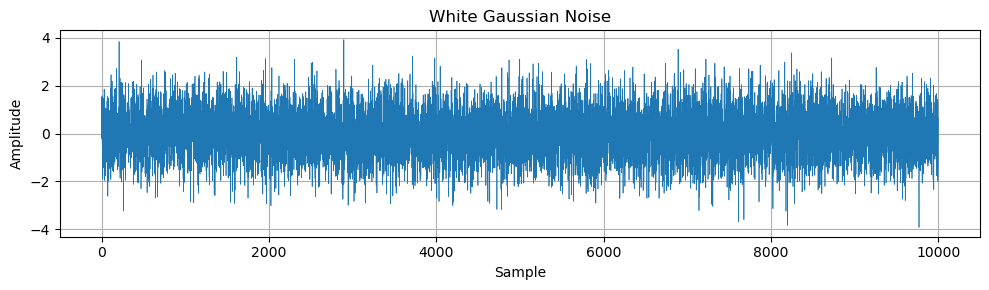

Mean: -0.0021 (theoretical: 0)
Variance: 1.0068 (theoretical: 1)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

# Parameters
N = 10000
mean_val = 0
std_dev = 1
fs = 1000  # Sampling frequency

# Generate white Gaussian noise
np.random.seed(42)
signal = np.random.normal(loc=mean_val, scale=std_dev, size=N)

# Plot the signal
plt.figure(figsize=(10, 3))
plt.plot(signal, linewidth=0.5)
plt.title("White Gaussian Noise")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Mean: {np.mean(signal):.4f} (theoretical: 0)")
print(f"Variance: {np.var(signal):.4f} (theoretical: {std_dev**2})")

## 2. Sample Autocorrelation vs Autocovariance

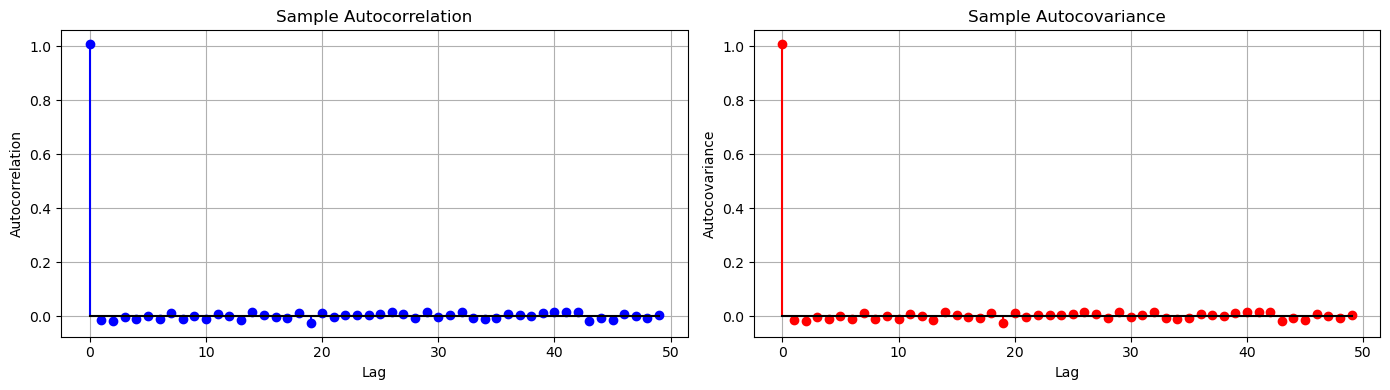

Autocorrelation at lag 0: 1.0068 (theoretical: 1)
Autocovariance at lag 0:  1.0068 (theoretical: 1)
Autocorrelation at lag 1: -0.014249 (theoretical: 0)
Autocovariance at lag 1:  -0.014254 (theoretical: 0)


In [2]:
# --- Autocorrelation Function ---
def autocorrelation(x):
    result = correlate(x, x, mode='full')
    result = result[result.size // 2:] / len(x)
    return result

autocorr = autocorrelation(signal)

# --- Autocovariance Function ---
signal_centered = signal - np.mean(signal)
autocov = autocorrelation(signal_centered)

# --- Plot comparison ---
max_lag = 50  # Show only first 50 lags for clarity
lags = np.arange(max_lag)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].stem(lags, autocorr[:max_lag], linefmt='b-', markerfmt='bo', basefmt='k-')
axes[0].set_title("Sample Autocorrelation")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(True)

axes[1].stem(lags, autocov[:max_lag], linefmt='r-', markerfmt='ro', basefmt='k-')
axes[1].set_title("Sample Autocovariance")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Autocovariance")
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Autocorrelation at lag 0: {autocorr[0]:.4f} (theoretical: {std_dev**2})")
print(f"Autocovariance at lag 0:  {autocov[0]:.4f} (theoretical: {std_dev**2})")
print(f"Autocorrelation at lag 1: {autocorr[1]:.6f} (theoretical: 0)")
print(f"Autocovariance at lag 1:  {autocov[1]:.6f} (theoretical: 0)")

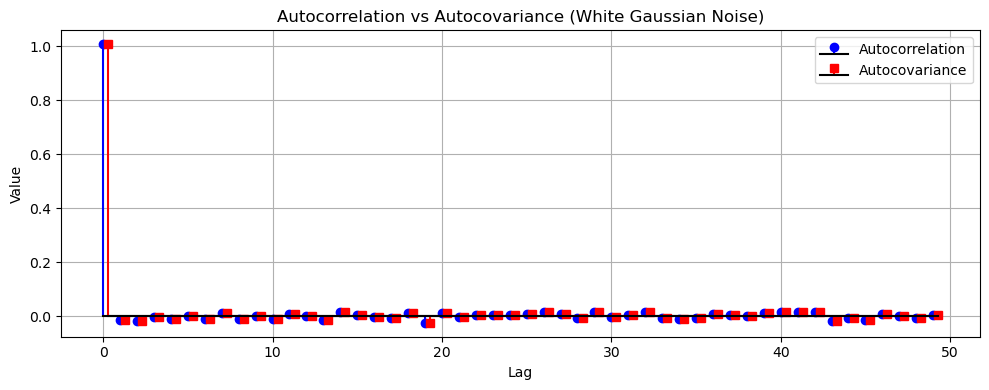

In [3]:
# --- Overlay comparison ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(lags, autocorr[:max_lag], linefmt='b-', markerfmt='bo', basefmt='k-', label='Autocorrelation')
ax.stem(lags + 0.3, autocov[:max_lag], linefmt='r-', markerfmt='rs', basefmt='k-', label='Autocovariance')
ax.set_title("Autocorrelation vs Autocovariance (White Gaussian Noise)")
ax.set_xlabel("Lag")
ax.set_ylabel("Value")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 3. PSD Estimation using FFT vs Analytical PSD

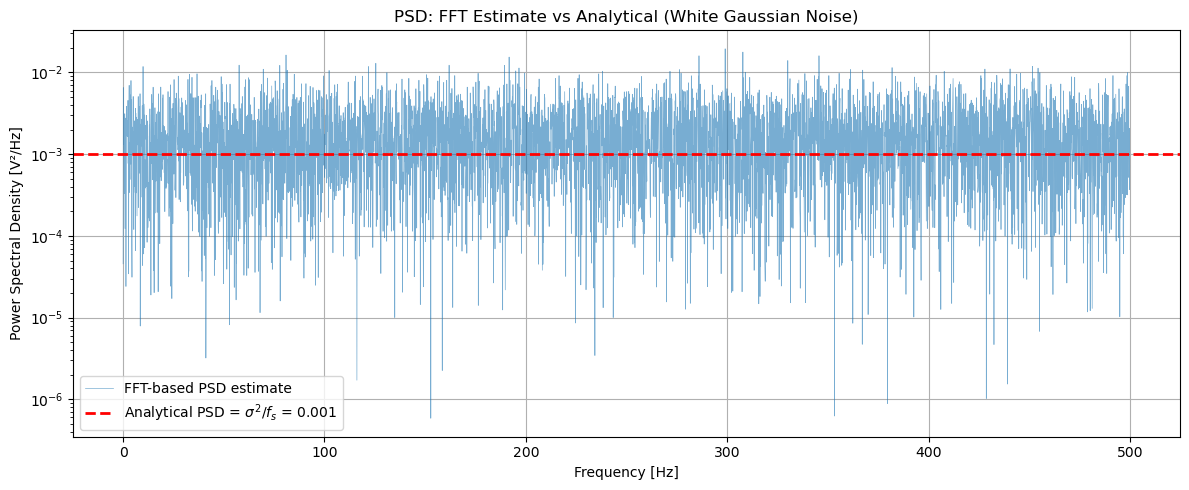

Analytical PSD (constant): 0.001000 V²/Hz
Mean of FFT PSD estimate:  0.002014 V²/Hz


In [4]:
# --- PSD estimation using FFT (Periodogram) ---
N_fft = len(signal)
X = np.fft.fft(signal)
Pxx_fft = (np.abs(X) ** 2) / (N_fft * fs)  # One-sided scaling below

# One-sided spectrum (positive frequencies only)
freqs = np.fft.fftfreq(N_fft, d=1/fs)
pos_mask = freqs >= 0
freqs_pos = freqs[pos_mask]
Pxx_onesided = 2 * Pxx_fft[pos_mask]
Pxx_onesided[0] /= 2       # DC component — no doubling
Pxx_onesided[-1] /= 2      # Nyquist — no doubling

# Analytical PSD for white noise: sigma^2 / fs
analytical_psd = std_dev**2 / fs

# --- Plot ---
plt.figure(figsize=(12, 5))
plt.semilogy(freqs_pos, Pxx_onesided, alpha=0.6, linewidth=0.5, label='FFT-based PSD estimate')
plt.axhline(y=analytical_psd, color='r', linewidth=2, linestyle='--', label=f'Analytical PSD = $\\sigma^2/f_s$ = {analytical_psd}')
plt.title("PSD: FFT Estimate vs Analytical (White Gaussian Noise)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power Spectral Density [V²/Hz]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Analytical PSD (constant): {analytical_psd:.6f} V²/Hz")
print(f"Mean of FFT PSD estimate:  {np.mean(Pxx_onesided):.6f} V²/Hz")

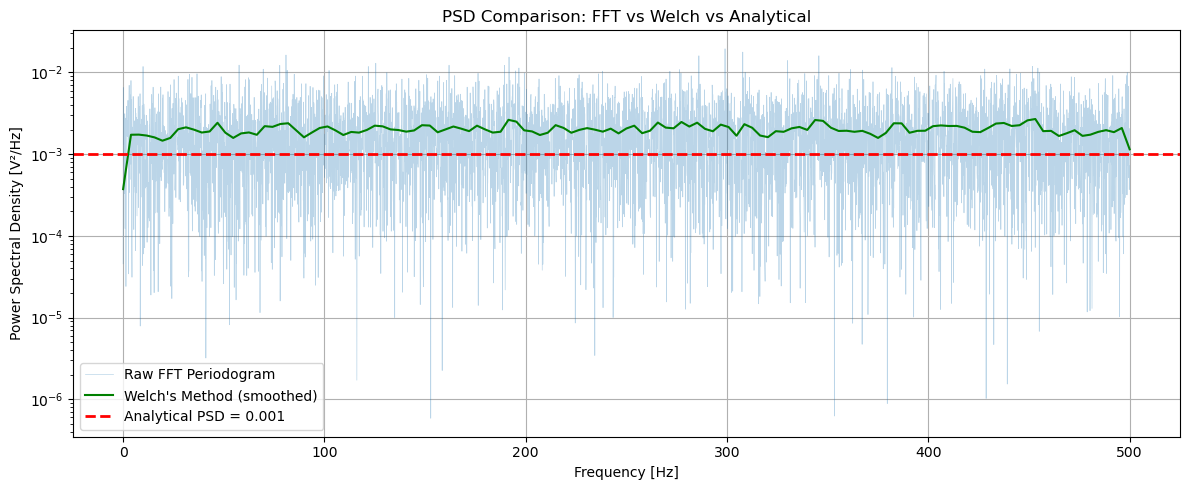

In [5]:
# --- Smoothed PSD (Welch) vs FFT vs Analytical ---
from scipy.signal import welch

f_welch, Pxx_welch = welch(signal, fs=fs, nperseg=256, noverlap=128, window='hann')

plt.figure(figsize=(12, 5))
plt.semilogy(freqs_pos, Pxx_onesided, alpha=0.3, linewidth=0.5, label='Raw FFT Periodogram')
plt.semilogy(f_welch, Pxx_welch, color='green', linewidth=1.5, label="Welch's Method (smoothed)")
plt.axhline(y=analytical_psd, color='r', linewidth=2, linestyle='--', label=f'Analytical PSD = {analytical_psd}')
plt.title("PSD Comparison: FFT vs Welch vs Analytical")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power Spectral Density [V²/Hz]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()